# FOSS Survey Analysis
---

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
print("All packages loaded")

All packages loaded


## Loading and Encoding Data

In [2]:
df = pd.read_csv('awareness_and_application_of_FOSS_responses.csv')
df = df.replace({'Aware':3, 'Partially Aware':2, 'Not Aware':1, 
            'Strongly disagree':1, 'Disagree':2, 'Neither agree nor disagree':3, 'Agree':4, 'Strongly agree':5,
            'Very difficult':1, 'Difficult':2, 'Neither difficult nor easy':3, 'Easy':4, 'Very easy':5, 
            'Very unlikely':1, 'Unlikely':2, 'Neutral':3, 'Likely':4, 'Very likely':5})
df = df.drop(columns=['Timestamp', 'B. Ed. Year', 'Type of Internship School'])
df = df.sort_values(by='Teaching Subject/ Method')
df.to_csv('FOSS_responses.csv', index=False)

In [3]:
print(df.columns)

Index(['Teaching Subject/ Method',
       'Awareness of different types of softwares [Proprietary Software]',
       'Awareness of different types of softwares [Free and Open-Source Software]',
       'Awareness of different types of softwares [Pirated Software]',
       'Awareness of different types of softwares [All of the above]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Libre office]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Open office]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Mozilla Firefox]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Chromium]',
       'Awareness  of various Free and Open-Source Software(FOSS) [GIMP]',
       'Awareness  of various Free and Open-Source Software(FOSS) [VLC media player]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Ubuntu]',
       'Awareness  of various Free and Open-Source Software(FOSS) [Open Shot]',
       'Awarene

#### Assigning scores to the categories
The mean was calculated across the categories for the different questions asked. The questions were prepared to check the experience and attitude of the users towards Free and Open-Source Softwares.

In [4]:
awareness = ['Awareness of different types of softwares [Proprietary Software]',
         'Awareness of different types of softwares [Free and Open-Source Software]', 
         'Awareness of different types of softwares [Pirated Software]']
application = ['Application of FOSS: [I used FOSS to prepare teaching-learning materials]',
            'Application of FOSS: [I used FOSS for lesson planning and assessment]',
            'Application of FOSS: [I regularly used at least one FOSS tool during my internship]']
usefulness = ['Perceived Usefulness: [FOSS helped me perform teaching tasks effectively]',
       'Perceived Usefulness: [FOSS is a good alternative to paid software]',
       'Perceived Usefulness: [FOSS improved my digital teaching skills]']
ease = ['Perceived Ease of Use: [FOSS tools were easy to use]',
       'Perceived Ease of Use: [FOSS tools were easy to use during classroom teaching]',
       'Perceived Ease of Use: [FOSS tools were user-friendly]']
intention = ['Behavioral Intention: [I intend to use FOSS in future teaching]',
       'Behavioral Intention: [I am interested in learning more about FOSS tools]',
       'Behavioral Intention: [I will recommend FOSS to other teachers]']
challenge = ['Challenges and Security [Lack of training limits my use of FOSS]',
       'Challenges and Security [Limited technical support affects my use of FOSS]']
security=['Challenges and Security [I feel FOSS tools are safe and secure for teaching use]']

# General-use tools (browsers, media — personally familiar)
general_tools = ['Awareness  of various Free and Open-Source Software(FOSS) [Mozilla Firefox]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Chromium]',
    'Awareness  of various Free and Open-Source Software(FOSS) [VLC media player]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Open office]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Libre office]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Ubuntu]',]
# Creative/media tools (classroom content creation)
creative_tools = ['Awareness  of various Free and Open-Source Software(FOSS) [GIMP]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Open Shot]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Audacity]',
    'Awareness  of various Free and Open-Source Software(FOSS) [MyPaint]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Tuxpaint]',]
# Pedagogy/education-specific tools
edu_tools = ['Awareness  of various Free and Open-Source Software(FOSS) [Geogebra]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Cmap]',
    'Awareness  of various Free and Open-Source Software(FOSS) [MAHARA]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Moodle]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Classroom 2.0]',
    'Awareness  of various Free and Open-Source Software(FOSS) [Google Earth]',
    'Awareness  of various Free and Open-Source Software(FOSS) [RCampus]',]
# Convert to numeric
for col in awareness + application + usefulness + ease + intention + challenge + security + general_tools + creative_tools + edu_tools:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# All of the above kept separate so as to not inflate the scores
df['Awareness_score']=df[awareness].mean(axis=1)
df['Aware_all_types']=df['Awareness of different types of softwares [All of the above]']
df['Awareness_general_score']=df[general_tools].mean(axis=1)
df['Awareness_creative_score']=df[creative_tools].mean(axis=1)
df['Awareness_edutool_score']=df[edu_tools].mean(axis=1)
# Application score
df['Application_score']=df[application].mean(axis=1)
df['Application_habitual_score']=df['Application of FOSS: [I regularly used at least one FOSS tool during my internship]']
# Perception on usefulness
df['Perception_on_Usefulness_score']=df[usefulness].mean(axis=1)
# Ease of use
df['Ease_of_use_score']=df[ease].mean(axis=1)
# Behavioural Intention
df['Intention_score']=df[intention].mean(axis=1)
# Challenge and Security
df['Challenge_score']=df[challenge].mean(axis=1)
# Credibility score
df['Security_score']=df[security].mean(axis=1)

score_cols=['Awareness_score', 'Aware_all_types', 'Awareness_general_score', 'Awareness_creative_score', 'Awareness_edutool_score',
            'Application_score', 'Application_habitual_score', 'Perception_on_Usefulness_score', 'Ease_of_use_score',
            'Intention_score', 'Challenge_score', 'Security_score']
print(f"Shape: {df.shape}  |  Groups: {df['Teaching Subject/ Method'].value_counts().to_dict()}")
df[score_cols].describe().round(3)

Shape: (91, 50)  |  Groups: {'Science': 46, 'Arts': 45}


,Awareness_score,Aware_all_types,Awareness_general_score,Awareness_creative_score,Awareness_edutool_score,Application_score,Application_habitual_score,Perception_on_Usefulness_score,Ease_of_use_score,Intention_score,Challenge_score,Security_score
count,91.000,91.000,91.000,91.000,91.000,91.000,91.000,91.000,91.000,91.000,70.000,51.000
mean,1.945,1.912,1.850,1.556,1.609,3.183,3.055,3.465,3.322,3.571,3.629,3.922
std,0.682,0.755,0.563,0.554,0.559,0.902,1.004,0.981,0.751,0.951,1.086,0.935
min,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
25%,1.333,1.000,1.500,1.000,1.143,2.667,2.000,3.000,3.000,3.000,4.000,4.000
50%,2.000,2.000,1.833,1.400,1.429,3.000,3.000,4.000,3.000,3.667,4.000,4.000
75%,2.333,2.000,2.167,2.000,2.000,4.000,4.000,4.000,4.000,4.000,4.000,4.000
max,3.000,3.000,3.000,3.000,3.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000


### Cronbach's alpha

In [5]:
def cronbach_alpha(data):
    """
    Compute Cronbach's alpha for a DataFrame of item responses.

    Formula:
        alpha = (k / (k-1)) * (1 - sum(sigma_i^2) / sigma_total^2)

    where:
        k             = number of items
        sigma_i^2     = variance of each individual item
        sigma_total^2 = variance of the row sums (total score)
    """
    data = data.dropna()
    k = data.shape[1]
    if k < 2:
        return np.nan

    item_variances = data.var(axis=0, ddof=1).sum()   # sum of item variances
    total_variance = data.sum(axis=1).var(ddof=1)     # variance of total scores

    alpha = (k / (k - 1)) * (1 - item_variances / total_variance)
    return round(alpha, 4)

def interpret_alpha(a):
    if a >= 0.90: return 'Excellent'
    if a >= 0.80: return 'Good'
    if a >= 0.70: return 'Acceptable'
    if a >= 0.60: return 'Questionable'
    return 'Poor'

constructs = {'Awareness — Software Types' : awareness, 'Awareness — General Tools' : general_tools,
    'Awareness — Creative Tools' : creative_tools, 'Awareness — Education Tools' : edu_tools,
    'Perceived Usefulness' : usefulness, 'Perceived Ease of Use' : ease, 'Application of FOSS' : application,
    'Behavioural Intention' : intention, 'Challenge / Barriers' : challenge, 'Security': security}

print(f"\n{'Construct':<30} {'Items':>5} {'Alpha':>7} {'Interpretation'}")
print("-" * 65)
results = {}
for name, cols in constructs.items():
    data  = df[cols].dropna()
    alpha = cronbach_alpha(data)
    interp = interpret_alpha(alpha)
    results[name] = {'k': len(cols), 'alpha': alpha, 'interpretation': interp}
    print(f"{name:<30} {len(cols):>5} {alpha:>7.4f}  {interp}")
    
print("\n\n=== ITEM-TOTAL CORRELATIONS (for detailed reporting) ===\n")
for name, cols in constructs.items():
    data = df[cols].dropna()
    total = data.sum(axis=1)
    print(f"\n{name}  (alpha = {results[name]['alpha']:.4f})")
    print(f"  {'Item':<55} {'r(item-total)':>14}")
    print("  " + "-" * 70)
    for col in cols:
        short = col.split('[')[-1].replace(']', '').strip()[:52]
        r = data[col].corr(total - data[col])   # corrected item-total
        print(f"  {short:<55} {r:>14.4f}")


Construct                      Items   Alpha Interpretation
-----------------------------------------------------------------
Awareness — Software Types         3  0.8381  Good
Awareness — General Tools          6  0.8125  Good
Awareness — Creative Tools         5  0.8312  Good
Awareness — Education Tools        7  0.8745  Good
Perceived Usefulness               3  0.9504  Excellent
Perceived Ease of Use              3  0.8816  Good
Application of FOSS                3  0.8934  Good
Behavioural Intention              3  0.9337  Excellent
Challenge / Barriers               2  0.9006  Excellent
Security                           1     nan  Poor


=== ITEM-TOTAL CORRELATIONS (for detailed reporting) ===


Awareness — Software Types  (alpha = 0.8381)
  Item                                                     r(item-total)
  ----------------------------------------------------------------------
  Proprietary Software                                            0.7214
  Free and Open-Source 

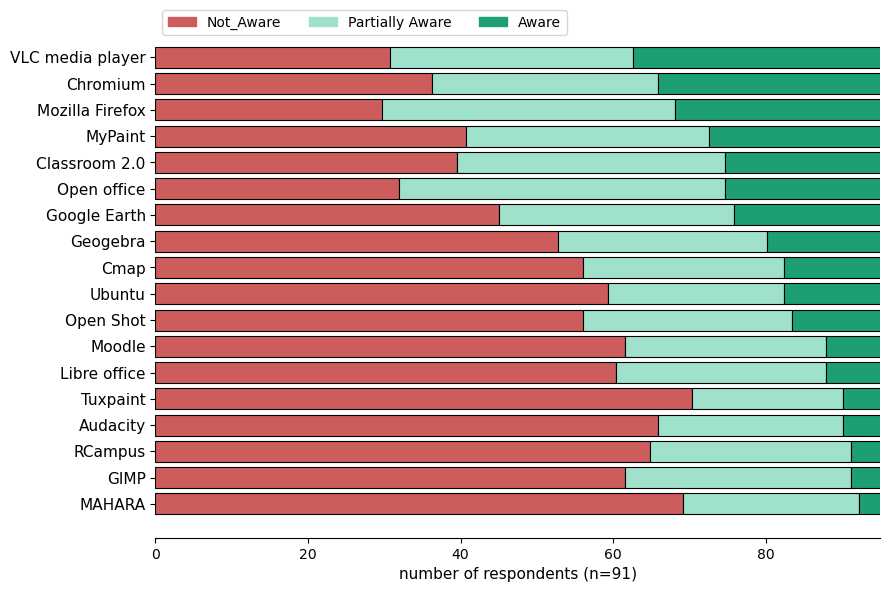

In [6]:
total = len(df)
tool_cols = general_tools + creative_tools + edu_tools
tools, not_aware, partially_aware, aware = [], [], [], []
for c in tool_cols:
    name = c.split('[')[-1].replace(']','')
    tools.append(name)

    na = (df[c] == 1).sum()
    pa = (df[c] == 2).sum()
    aw = (df[c] == 3).sum()

    # convert to percentage
    not_aware.append((na / total) * 100)
    partially_aware.append((pa / total) * 100)
    aware.append((aw / total) * 100)
# sort by "Not Aware" in descending, most unaware at the bottom
order = sorted(range(len(tools)), key=lambda i:aware[i])
tools = [tools[i] for i in order]
not_aware = [not_aware[i] for i in order]
partially_aware = [partially_aware[i] for i in order]
aware = [aware[i] for i in order]

# Plot
fig, ax = plt.subplots(figsize=(9,6))
y = range(len(tools))

# Stack order: Not Aware | Partially Aware | Aware
b1 = ax.barh(list(y), not_aware, color='indianred', edgecolor='black', linewidth=0.8)
b2 = ax.barh(list(y), partially_aware, left= not_aware, color='#9FE1CB', edgecolor='black', linewidth=0.8)
b3 = ax.barh(list(y), aware, left=[n+p for n, p in zip(not_aware, partially_aware)], color='#1D9E75', edgecolor='black', linewidth=0.8)

ax.set_yticks(list(y))
ax.set_yticklabels(tools, color='black', fontsize=11)
ax.set_xlabel('number of respondents (n=91)', color='black', fontsize=11)
ax.set_xlim(0, 95)
ax.tick_params(color='black')
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)

legend = [mpatches.Patch(color='indianred', label='Not_Aware'), mpatches.Patch(color='#9FE1CB', label='Partially Aware'), 
         mpatches.Patch(color='#1D9E75', label='Aware')]
ax.legend(handles=legend,loc='upper left', fontsize=10, ncol=3, bbox_to_anchor=(0, 1.04), frameon=True)
plt.tight_layout()
plt.savefig('tool_awareness.jpg', dpi=300)
plt.show()

## Pearson and Spearman correlation
Awareness uses a 3-point scale, Application a 5-point scale. Pearson assumes continuity; with only 3 levels that assumption is mildly violated. Spearman is rank-based and safer for ordinal data. Reporting both and seeing them agree makes the conclusion robust.

In [7]:
x, y = df['Awareness_score'], df['Application_score']
r, p_r = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)

print(f'Pearson correlation coefficient: r = {r:.4f}, p value = {p_r:.3f}')
print(f'Spearman correlation coefficient: rho = {rho:.4f}, p value = {p_rho:.3f}')
if abs(r - rho) < 0.05:
    print("  Pearson and Spearman agree closely -> scale mismatch is not distorting.")
else:
    print("  Pearson and Spearman diverge -> prefer Spearman here.")

Pearson correlation coefficient: r = 0.3841, p value = 0.000
Spearman correlation coefficient: rho = 0.4191, p value = 0.000
  Pearson and Spearman agree closely -> scale mismatch is not distorting.


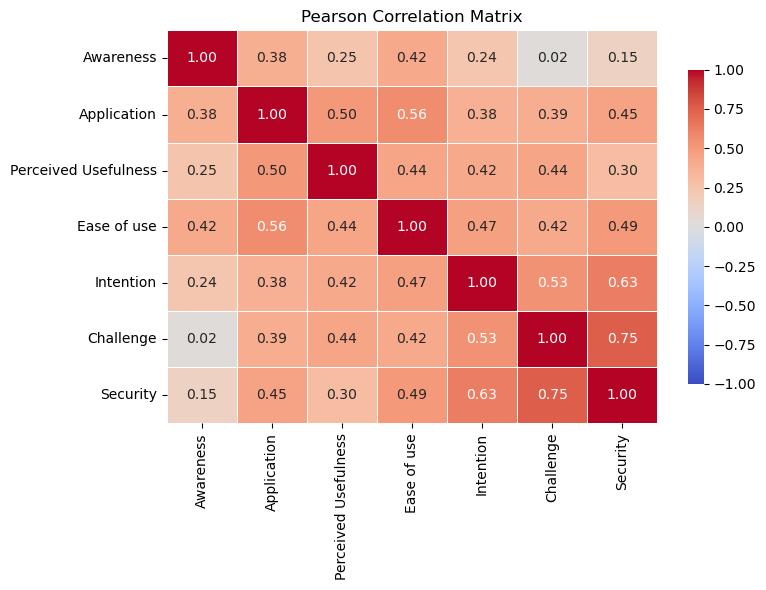

In [8]:
corr_cols = ['Awareness_score', 'Application_score',  'Perception_on_Usefulness_score', 'Ease_of_use_score',
            'Intention_score', 'Challenge_score', 'Security_score']
pearson_matrix = df[corr_cols].corr(method='pearson')
labels_h = ['Awareness', 'Application',  'Perceived Usefulness', 'Ease of use',
            'Intention', 'Challenge', 'Security']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap= 'coolwarm', center=0,
           vmin=-1, vmax=1, xticklabels=labels_h, yticklabels=labels_h,
           linewidth=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('pearson_heatmap.jpg', dpi=300)
plt.show()

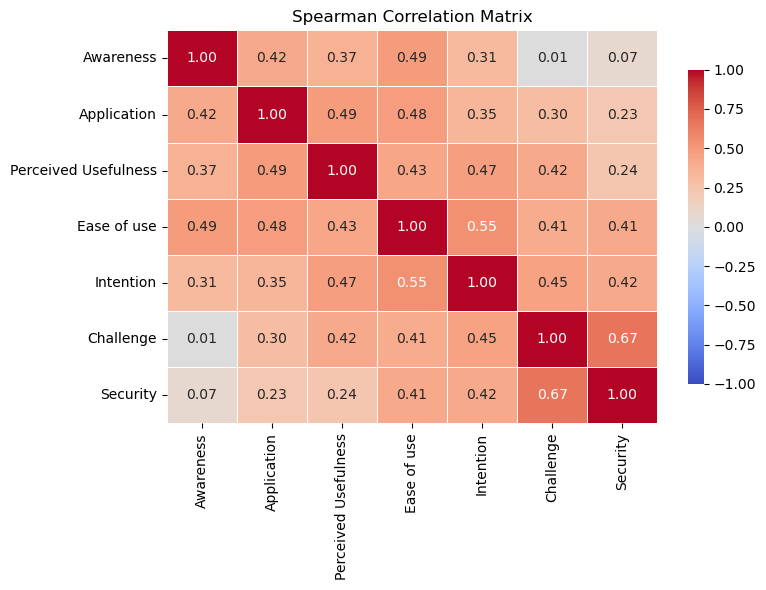

In [9]:
corr_cols = ['Awareness_score', 'Application_score',  'Perception_on_Usefulness_score', 'Ease_of_use_score',
            'Intention_score', 'Challenge_score', 'Security_score']
spearman_matrix = df[corr_cols].corr(method='spearman')
labels_h = ['Awareness', 'Application',  'Perceived Usefulness', 'Ease of use',
            'Intention', 'Challenge', 'Security']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap= 'coolwarm', center=0,
           vmin=-1, vmax=1, xticklabels=labels_h, yticklabels=labels_h,
           linewidth=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Spearman Correlation Matrix')
plt.tight_layout()
plt.savefig('spearman_heatmap.jpg', dpi=300)
plt.show()

## Two Sample t-test

In [10]:
construct_map = {'Awareness': 'Awareness_score', 'Application': 'Application_score',
                'Usefulness': 'Perception_on_Usefulness_score', 'Ease of Use': 'Ease_of_use_score',
                'Intention': 'Intention_score', 'Challenges': 'Challenge_score', 'Security': 'Security_score'}
rows = []
group_col = 'Teaching Subject/ Method'
for name, col in construct_map.items():
    arts = df[df[group_col] == 'Arts'][col].dropna()
    science = df[df[group_col] == 'Science'][col].dropna()

    # Independent sample t-test
    t, p = stats.ttest_ind(arts, science, equal_var=False)
    # Welch’s t-test (recommended)
    rows.append({'Construct': name, 'Arts_Mean': round(arts.mean(), 3), 'Science_Mean': round(science.mean(), 3),
        'Arts_SD': round(arts.std(), 3), 'Science_SD': round(science.std(), 3), 't': round(t, 3),
        'p': round(p, 4),'Difference': ('Arts Higher' if arts.mean() > science.mean() and p < 0.05
            else 'Science Higher' if science.mean() > arts.mean() and p < 0.05
            else 'No Significant Difference')})
ttest_df = pd.DataFrame(rows)
print(ttest_df.to_string(index=False))

  Construct  Arts_Mean  Science_Mean  Arts_SD  Science_SD      t      p                Difference
  Awareness      1.933         1.957    0.610       0.752 -0.162 0.8719 No Significant Difference
Application      3.156         3.210    0.963       0.847 -0.287 0.7749 No Significant Difference
 Usefulness      3.526         3.406    0.909       1.054  0.583 0.5616 No Significant Difference
Ease of Use      3.393         3.254    0.766       0.738  0.881 0.3807 No Significant Difference
  Intention      3.541         3.601    0.908       1.000 -0.303 0.7624 No Significant Difference
 Challenges      3.765         3.500    1.061       1.108  1.021 0.3108 No Significant Difference
   Security      4.125         3.741    0.947       0.903  1.479 0.1458 No Significant Difference


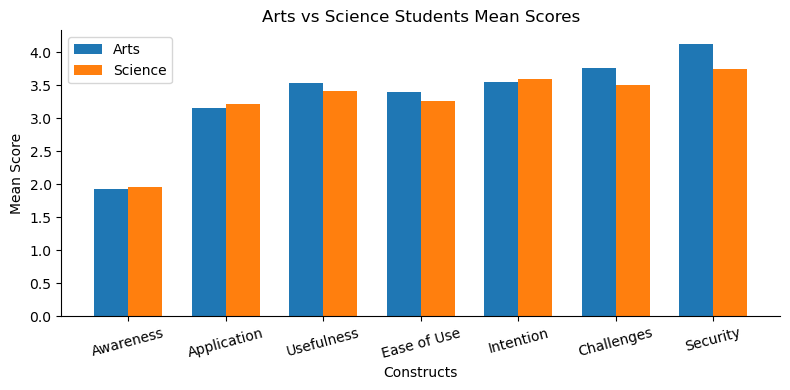

In [11]:
x = np.arange(len(ttest_df['Construct']))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, ttest_df['Arts_Mean'], width, label='Arts')
ax.bar(x + width/2, ttest_df['Science_Mean'], width, label='Science')
ax.set_xlabel('Constructs')
ax.set_ylabel('Mean Score')
ax.set_title('Arts vs Science Students Mean Scores')
ax.set_xticks(x)
ax.set_xticklabels(ttest_df['Construct'], rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('t-test difference.png', dpi=300)
plt.show()

## Technology Acceptance Model (TAM) — Full Multiple Regression

### Theoretical framework

The Technology Acceptance Model (Davis, 1989) proposes that technology adoption is determined
by two core perceptions: **Perceived Usefulness** (PU) and **Perceived Ease of Use** (PEOU).
Extended TAM frameworks additionally include **Behavioral Intention** (BI) as a mediating
variable — the premise being that usefulness and ease first shape the *intention* to use a
technology, and intention then drives *actual use*.

In the context of this study, the full TAM path is:

```
Awareness → Perceived Usefulness ┐
                                  ├──→ Behavioral Intention ──→ Application
Awareness → Ease of Use          ┘
```

**Constructs in this regression:**

| Predictor | What it measures | Scale |
|-----------|-----------------|-------|
| Awareness | Knowledge of software types (Proprietary, FOSS, Pirated) | 1–3 ordinal |
| Perceived Usefulness | Experiential benefit of FOSS in teaching tasks and skill development | 1–5 Likert |
| Ease of Use | Perceived ease of FOSS in general and classroom contexts | 1–5 Likert |
| Behavioral Intention | Intent to use FOSS in future; interest in learning more | 1–5 Likert |

**Outcome:** Application of FOSS (preparing materials, lesson planning, habitual use) — 1–5 Likert

In [12]:
# TAM Model 1
# Predicting Behavioural Intention
X1 = df[['Awareness_score', 'Perception_on_Usefulness_score', 'Ease_of_use_score']]
y1 = df['Intention_score']
tam_bi = pg.linear_regression(X1, y1)
print(tam_bi[['names','coef','se','T','pval','r2','adj_r2','CI2.5','CI97.5']].to_string(index=False))
adj_r2_bi = tam_bi['adj_r2'].iloc[1]
r2_bi = tam_bi['r2'].iloc[1]
print(f"\nR² = {r2_bi:.4f}")
print(f"Adj. R² = {adj_r2_bi:.4f}")

                         names     coef       se        T     pval       r2   adj_r2     CI2.5   CI97.5
                     Intercept 1.181425 0.429871 2.748324 0.007282 0.275914 0.250946  0.327010 2.035840
               Awareness_score 0.048721 0.140547 0.346652 0.729690 0.275914 0.250946 -0.230632 0.328074
Perception_on_Usefulness_score 0.255300 0.099019 2.578290 0.011611 0.275914 0.250946  0.058489 0.452111
             Ease_of_use_score 0.424572 0.137861 3.079708 0.002773 0.275914 0.250946  0.150558 0.698586

R² = 0.2759
Adj. R² = 0.2509


In [13]:
# TAM Model 2
# Predicting Actual Application
X2 = df[['Intention_score']]
y2 = df['Application_score']
tam_app = pg.linear_regression(X2, y2)
print(tam_app[['names','coef','se','T','pval','r2','adj_r2','CI2.5','CI97.5']].to_string(index=False))
adj_r2_app = tam_app['adj_r2'].iloc[1]
r2_app = tam_app['r2'].iloc[1]
print(f"\nR² = {r2_app:.4f}")
print(f"Adj. R² = {adj_r2_app:.4f}")

          names     coef       se        T         pval       r2   adj_r2    CI2.5   CI97.5
      Intercept 1.889831 0.343151 5.507286 3.490470e-07 0.145883 0.136286 1.207997 2.571664
Intention_score 0.362129 0.092881 3.898865 1.870860e-04 0.145883 0.136286 0.177577 0.546682

R² = 0.1459
Adj. R² = 0.1363


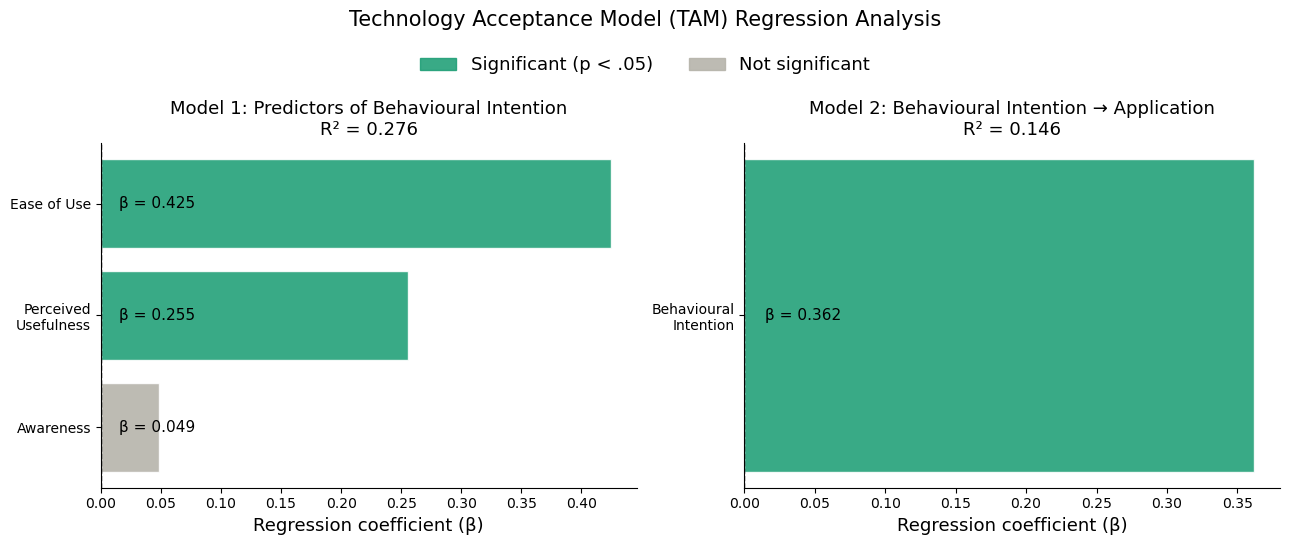

In [14]:
# Combined TAM Regression Plots
# Model 1: Predictors of Behavioural Intention
# Model 2: Behavioural Intention predicting Application
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MODEL 1
tam_plot1 = tam_bi.iloc[1:].copy()
colors_c1 = ['#1D9E75' if p < 0.05 else '#B4B2A9' for p in tam_plot1['pval']]
bars1 = axes[0].barh(['Awareness','Perceived\nUsefulness','Ease of Use'], tam_plot1['coef'],
    # xerr=(tam_plot1['coef'] - tam_plot1['CI2.5'],tam_plot1['CI97.5'] - tam_plot1['coef']),
    color=colors_c1,alpha=0.88, edgecolor='white', capsize=5,error_kw={'elinewidth': 1.5,'ecolor': '#555'})
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
for bar, (_, row) in zip(bars1, tam_plot1.iterrows()):
    xpos = + 0.015
    axes[0].text(xpos,bar.get_y() + bar.get_height()/2,f"β = {row['coef']:.3f}",va='center',fontsize=11)
axes[0].set_title(f'Model 1: Predictors of Behavioural Intention\n' f'R² = {r2_bi:.3f}', fontsize=13)
axes[0].set_xlabel('Regression coefficient (β)', fontsize=13)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# MODEL 2
tam_plot2 = tam_app.iloc[1:].copy()
colors_c2 = ['#1D9E75' if p < 0.05 else '#B4B2A9' for p in tam_plot2['pval']]
bars2 = axes[1].barh(['Behavioural\nIntention'], tam_plot2['coef'],
    # xerr=(tam_plot2['coef'] - tam_plot2['CI2.5'], tam_plot2['CI97.5'] - tam_plot2['coef']),
    color=colors_c2,alpha=0.88, edgecolor='white', capsize=5,error_kw={'elinewidth': 1.5, 'ecolor': '#555'})
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
for bar, (_, row) in zip(bars2, tam_plot2.iterrows()):
    xpos =  + 0.015
    axes[1].text(xpos, bar.get_y() + bar.get_height()/2,f"β = {row['coef']:.3f}", va='center', fontsize=11)
axes[1].set_title(f'Model 2: Behavioural Intention → Application\n'f'R² = {r2_app:.3f}',fontsize=13)
axes[1].set_xlabel('Regression coefficient (β)', fontsize=13)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
sig_p = mpatches.Patch(color='#1D9E75',alpha=0.88,label='Significant (p < .05)')
nosig_p = mpatches.Patch(color='#B4B2A9',alpha=0.88,label='Not significant')
fig.legend(handles=[sig_p, nosig_p],loc='upper center', ncol=2, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Technology Acceptance Model (TAM) Regression Analysis',fontsize=15,y=1.08)
plt.tight_layout()
plt.savefig('combined_tam_regression.png',dpi=300,bbox_inches='tight')
plt.show()

## Multiple Regression Analysis Predicting FOSS Application

To examine the factors influencing student teachers’ application of Free and Open-Source Software (FOSS) during internship, multiple regression analysis was conducted within the framework of the Technology Acceptance Model (TAM; Davis, 1989). The dependent variable was the composite **Application score**, representing the extent to which participants used FOSS for lesson planning, preparation of teaching-learning materials, assessment, and other internship-related activities.

The predictor variables included:

- Awareness of FOSS tools  
- Perceived Usefulness  
- Perceived Ease of Use  
- Behavioral Intention to use FOSS  

The overall regression model explained approximately **41.4%** of the variance in FOSS Application $R^2 = 0.414$, Adjusted $R^2 = 0.386$.

Among the predictors, **Perceived Ease of Use** emerged as the strongest significant predictor of Application ($\beta = 0.396$, $p = .002$), indicating that student teachers were more likely to apply FOSS tools when they perceived them as easy to learn and operate. **Perceived Usefulness** also significantly predicted Application ($\beta = 0.263$, $p = .004$), suggesting that participants who found FOSS practically beneficial were more likely to integrate it into internship activities.

Although **Awareness** showed a positive association with Application, it did not reach conventional levels of statistical significance ($\beta = 0.208$, $p = .088$). Similarly, **Behavioral Intention** did not independently predict Application in the full regression model ($\beta = 0.066$, $p = .476$).

The non-significant effect of Behavioral Intention suggests that its influence may overlap with Perceived Usefulness and Ease of Use. The findings indicate that actual FOSS application during internship is influenced more directly by practical usability and perceived value than by intention alone. Overall, the results partially support the Technology Acceptance Model and highlight the importance of usability-related factors in technology adoption during teaching internship.